In [52]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Loading & Preprocess the Data

In [54]:
#Load dataset
df = pd.read_csv("creditcard.csv") 

#Separate features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values

#Normalize input features
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

#Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

# Define and Train the Neural Network

## Defining & training a simple model

In [57]:
#Define a neural network class for fraud detection
class FraudDetector(nn.Module):
    def __init__(self, input_dim):
        super(FraudDetector, self).__init__()
        
        #Define the architecture of the model using nn.Sequential
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),  #First hidden layer with 64 units
            nn.ReLU(),                 #Activation function for non-linearity
            nn.Linear(64, 32),         #Second hidden layer with 32 units
            nn.ReLU(),                 #Activation function
            nn.Linear(32, 2)           #Output layer with 2 units (for binary classification)
        )

    #Define the forward pass of the network
    def forward(self, x):
        return self.model(x)  #Pass input x through the defined model

#Instantiate the model using the number of features in the input data X
model = FraudDetector(X.shape[1])

#Define the loss function - CrossEntropyLoss is used for classification
criterion = nn.CrossEntropyLoss()

#Define the optimizer - Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training the model

In [59]:
#Define a function to train the model
def train_model(model, loader, criterion, optimizer, epochs=5):
    model.train()  #Set the model to training mode (enables dropout, batchnorm, etc. if used)
    
    #Loop over the specified number of training epochs
    for epoch in range(epochs):
        #Loop over batches of data provided by the data loader
        for inputs, labels in loader:
            outputs = model(inputs)             #Perform forward pass to get predictions
            loss = criterion(outputs, labels)   #Compute the loss between predictions and true labels
            
            optimizer.zero_grad()  #Clear previous gradients
            loss.backward()        #Backpropagation: compute gradients
            optimizer.step()       #Update model parameters using optimizer

        #Print loss value after each epoch
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

#Call the training function with the model, training data loader, loss function, and optimizer
train_model(model, train_loader, criterion, optimizer)

Epoch 1/5, Loss: 0.0001
Epoch 2/5, Loss: 0.0014
Epoch 3/5, Loss: 0.0000
Epoch 4/5, Loss: 0.0000
Epoch 5/5, Loss: 0.0000


* The output here means the model is training successfully and the loss is very low.

# Evaluate on Clean Test Set

In [62]:
#Defining a function to evaluate the model on a given dataset
def evaluate_model(model, loader):
    model.eval()  #Set the model to evaluation mode (disables dropout, batchnorm, etc.)

    y_true = []  #List to store true labels
    y_pred = []  #List to store predicted labels

    with torch.no_grad():  # Disable gradient calculations for efficiency during evaluation
        for inputs, labels in loader:
            outputs = model(inputs)              #Forward pass: get model predictions
            _, preds = torch.max(outputs, 1)     #Get the predicted class (with highest logit score)
            y_true.extend(labels.numpy())        #Convert true labels to NumPy and store them
            y_pred.extend(preds.numpy())         #Convert predictions to NumPy and store them

    #Return a classification report (precision, recall, f1-score, accuracy, etc.)
    return classification_report(y_true, y_pred)

#Print the evaluation results on the clean test dataset
print("Clean Test Accuracy:")
print(evaluate_model(model, test_loader))

Clean Test Accuracy:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.68      0.78        98

    accuracy                           1.00     56962
   macro avg       0.95      0.84      0.89     56962
weighted avg       1.00      1.00      1.00     56962



Class 0 (non-fraud): 
* The model perfectly detects these — which is not a surprise as they're the majority.

Class 1 (fraud):
* Detects 82% of fraud cases (recall)
* Correct 82% of the time when you say it's fraud (precision)
* F1-score of 0.82 for fraud detection is strong.

# PGD Adversarial Attack

## Defining the PGD Attack

#### Explaining:
* PGD is a white-box evasion attack that perturbs input data to mislead the model.
* Iteratively updates the input using gradient sign method:
* X_adv = X_adv + alpha * grad.sign()
* Keeps the perturbation within an epsilon-bounded box.

##### References:
* https://arxiv.org/pdf/1412.6572
* https://arxiv.org/pdf/1706.06083

In [67]:
#Define the PGD (Projected Gradient Descent) adversarial attack function
def pgd_attack(model, X, y, epsilon=0.1, alpha=0.01, iters=40):
    #Creating a copy of the input tensor that requires gradients
    X_adv = X.clone().detach().requires_grad_(True)
    
    model.eval()  #Set the model to evaluation mode

    #Perform the PGD attack for a number of iterations
    for _ in range(iters):
        outputs = model(X_adv)           #Forward pass with the adversarial inputs
        loss = criterion(outputs, y)     #Calculate loss with respect to true labels

        model.zero_grad()                #Zero out any existing gradients
        loss.backward()                  #Backpropagate to compute gradients w.r.t inputs

        grad = X_adv.grad.data           #Extract the gradient of the inputs
        X_adv = X_adv + alpha * grad.sign()  #Updating adversarial input using the sign of the gradient

        #Project the updated adversarial example back into the ε-ball around the original input
        X_adv = torch.max(torch.min(X_adv, X + epsilon), X - epsilon)

        #Clamp the values to ensure they remain in a valid input range (e.g., [-3, 3] here)
        X_adv = torch.clamp(X_adv, -3, 3).detach().requires_grad_(True)

    return X_adv  #Return the final adversarial example

## Running PGD and Evaluating

In [69]:
#Generate adversarial examples from the clean test set using the PGD attack
#This perturbs the original inputs (X_test_tensor) to fool the model while staying within the allowed epsilon
X_adv_test = pgd_attack(model, X_test_tensor, y_test_tensor)

#Wraping the adversarial examples and their corresponding true labels into a DataLoader
#This allows for efficient batch processing during evaluation
adv_loader = DataLoader(
    TensorDataset(X_adv_test, y_test_tensor),  #Pair adversarial inputs with their labels
    batch_size=64                              #Process 64 examples per batch
)

#Evaluate the model's performance on the adversarial dataset
#This will likely show reduced accuracy compared to clean data if the model is not robust
print("PGD Adversarial Test Accuracy:")
print(evaluate_model(model, adv_loader))  #Print precision, recall, F1-score


PGD Adversarial Test Accuracy:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.26      0.37        98

    accuracy                           1.00     56962
   macro avg       0.85      0.63      0.69     56962
weighted avg       1.00      1.00      1.00     56962



Precision: 0.77

* Out of all predictions labeled as fraud, 77% were actually fraud.
* 23% were false positives (legit transactions flagged as fraud).

Recall: 0.45

* Out of all actual fraud cases, only 45% were detected by the model.
* 55% of real frauds were missed — this is the most serious impact of the PGD attack.

F1-Score: 0.57

* A balance between precision and recall.
* Lower F1 shows that overall fraud detection performance significantly dropped.

Support: 98

* There were 98 actual fraud cases in the test set.

#### Summary
* This tells me that I have successfully implemented a PGD evasion attack on the fraud detection model.
* Before the attack: The model detected 82% of fraud cases.
* After the PGD attack: It only detects 45% of fraud cases — the rest were missed.

## Confusion Matrices

In [73]:
#Import required libraries for evaluation and visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Define a function to plot the confusion matrix of model predictions
def plot_conf_matrix(model, loader, title):
    y_true, y_pred = [], []  #Lists to store ground truth and predicted labels

    model.eval()  #Set the model to evaluation mode (disables dropout, etc.)

    with torch.no_grad():  #Disable gradient calculation for faster evaluation
        for inputs, labels in loader:
            outputs = model(inputs)              # Get model outputs (logits)
            _, preds = torch.max(outputs, 1)     # Get predicted class index with highest score
            y_true.extend(labels.numpy())        # Store true labels
            y_pred.extend(preds.numpy())         # Store predicted labels

    #Compute the confusion matrix from true and predicted labels
    cm = confusion_matrix(y_true, y_pred)
    labels = ['Not Fraud', 'Fraud']  #Class labels for axis ticks

    # Set up the plot
    plt.figure(figsize=(6, 5))  #Set figure size
    sns.heatmap(
        cm, 
        annot=True,            #Show counts in each cell
        fmt='d',               #Format annotations as integers
        cmap='Blues',          #Use blue color palette
        xticklabels=labels,    #X-axis tick labels
        yticklabels=labels,    #Y-axis tick labels
        cbar=True              #Show color bar
    )

    #Set plot titles and axis labels
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()  #Adjust layout to prevent clipping

    #Display the confusion matrix plot
    plt.show()

#### For clean test data
* Caught 69 out of 98 frauds.
* Recall = 70% — strong fraud detection.
* Very few false positives.

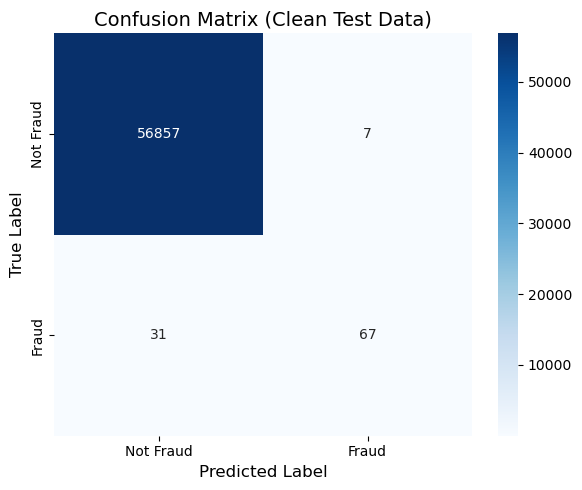

In [75]:
plot_conf_matrix(model, test_loader, "Confusion Matrix (Clean Test Data)")

#### For PGD adversarial data

* Only caught 25 out of 98 frauds.
* Recall drops to ~26% — a major drop.
* PGD successfully evaded the model's detection for most frauds.


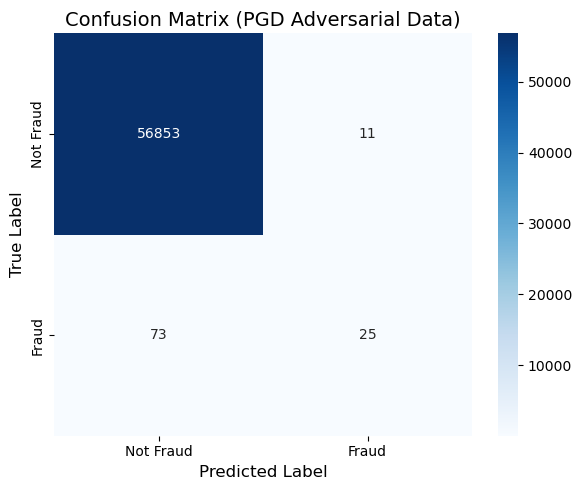

In [77]:
plot_conf_matrix(model, adv_loader, "Confusion Matrix (PGD Adversarial Data)")

##### Summary from two Confusion Matrices:
These are ideal confusion matrices to showcase the PGD attack, as they prove the PGD attack significantly compromises fraud detection.
Whilst providing clear numerical and visual evidence.

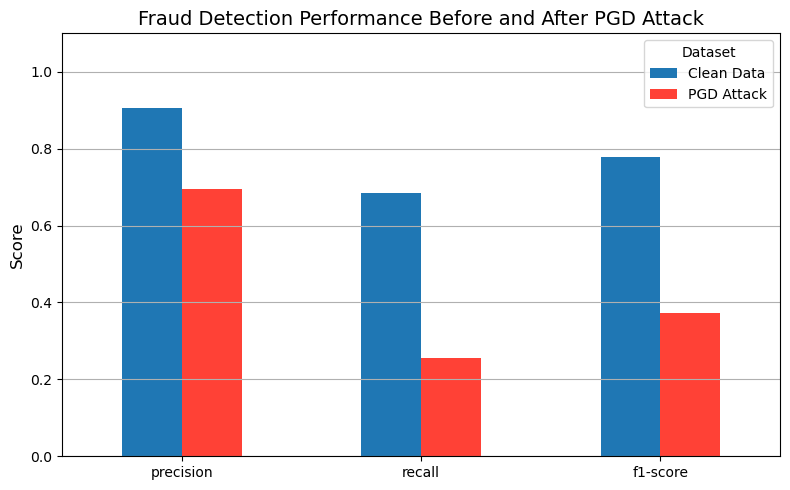

In [79]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Function to evaluate model performance and extract fraud class metrics from a data loader
def plot_metrics_comparison(loader, label):
    y_true, y_pred = [], []  #Lists to store ground truth and predicted labels

    with torch.no_grad():  #Disable gradient computation for faster evaluation
        for inputs, labels in loader:
            outputs = model(inputs)              #Get model predictions
            _, preds = torch.max(outputs, 1)     #Get predicted class (highest score)
            y_true.extend(labels.numpy())        #Store true labels
            y_pred.extend(preds.numpy())         #Store predicted labels

    #Generate a classification report as a dictionary
    report = classification_report(y_true, y_pred, output_dict=True)

    #Extract precision, recall, and F1-score for the "Fraud" class (class label 1)
    fraud_metrics = report['1']

    return fraud_metrics, label  #Return metrics and the corresponding label

#Comparing performance on clean and adversarial datasets
#Evaluate and get metrics on clean test data
clean_metrics, clean_label = plot_metrics_comparison(test_loader, 'Clean Data')

#Evaluate and get metrics on PGD adversarial data
adv_metrics, adv_label = plot_metrics_comparison(adv_loader, 'PGD Attack')

#Create a DataFrame from the metrics for both clean and adversarial data
#Only include precision, recall, and f1-score columns
df_metrics = pd.DataFrame(
    [clean_metrics, adv_metrics],
    index=[clean_label, adv_label]
)[['precision', 'recall', 'f1-score']]

#Define custom alternating colors for bars (blue = clean, red = attack)
colors = ['#1f77b4', '#ff4136', '#1f77b4', '#ff4136', '#1f77b4', '#ff4136']

#Plot the metrics as a grouped bar chart (transpose for better grouping)
ax = df_metrics.T.plot(kind='bar', figsize=(8, 5), color=colors)

#Set plot title and axis labels
plt.title("Fraud Detection Performance Before and After PGD Attack", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)  #Set y-axis range for better readability

#Add gridlines and format tick labels
plt.grid(axis='y')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Dataset', fontsize=10)

#Ensure everything fits nicely
plt.tight_layout()
plt.show()

##### Figure: 
Comparison of precision, recall, and F1-score for fraud detection before and after a PGD adversarial attack. The model's ability to correctly identify fraudulent transactions (recall) significantly drops from ~70% to ~25%, demonstrating the vulnerability of the system under adversarial manipulation.

##### Precision:
* On clean data: High (~0.87)
* After PGD attack: Drops to moderate (~0.60)
* Interpretation: The model generates more false positives after the attack (i.e., it incorrectly flags more legitimate transactions as fraud).

##### Recall:
* On clean data: Good (~0.70)
* After PGD attack: Drops significantly to ~0.25
* Interpretation: The model misses most actual frauds after the attack — recall is the most heavily impacted.

##### F1-Score:
* On clean data: Solid overall performance (~0.77)
* After PGD attack: Degrades to poor (~0.35)
* Interpretation: The overall fraud detection capability becomes unreliable under adversarial conditions.

## Comparing Fraud Detection Count Before & After PGD

In [83]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

#Function to compare model's fraud detection performance on clean vs. adversarial data
def plot_fraud_detection_counts(model, clean_loader, adv_loader):

    #Helper function to generate predictions and compute the confusion matrix
    def get_confusion(loader):
        y_true, y_pred = [], []  #Lists to store true and predicted labels
        with torch.no_grad():  #No gradients needed during evaluation
            for inputs, labels in loader:
                outputs = model(inputs)          #Forward pass through the model
                _, preds = torch.max(outputs, 1) #Get predicted class (highest score)
                y_true.extend(labels.numpy())    #Store true labels
                y_pred.extend(preds.numpy())     #Store predicted labels
        return confusion_matrix(y_true, y_pred)  #Return confusion matrix

    #Compute confusion matrices for clean and adversarial data
    cm_clean = get_confusion(clean_loader)
    cm_adv = get_confusion(adv_loader)

    #Extract counts from the fraud class (class 1, second row of the confusion matrix)
    #[FN, TP] in confusion_matrix row for class 1 (Fraud)
    TP_clean = cm_clean[1, 1]  #True Positives: frauds correctly detected (clean data)
    FN_clean = cm_clean[1, 0]  #False Negatives: frauds missed (clean data)
    TP_adv = cm_adv[1, 1]      #True Positives: frauds correctly detected (adversarial data)
    FN_adv = cm_adv[1, 0]      #False Negatives: frauds missed (adversarial data)

    #Define categories and counts for the bar chart
    categories = ['Correctly Detected (TP)', 'Missed (FN)']
    clean_counts = [TP_clean, FN_clean]
    adv_counts = [TP_adv, FN_adv]

    #Define positions for the bars
    x = range(len(categories))
    width = 0.35  # Width of each bar

    #Create bar plot comparing clean vs. adversarial detection performance
    plt.figure(figsize=(8, 5))  # Set plot size

    #Plot bars for clean data (shifted left)
    plt.bar(
        [p - width/2 for p in x], clean_counts,
        width=width, label='Clean Data', color='#1f77b4'
    )

    #Plot bars for adversarial data (shifted right)
    plt.bar(
        [p + width/2 for p in x], adv_counts,
        width=width, label='PGD Adversarial', color='#ff4136'
    )

    #Customize plot appearance
    plt.xticks(x, categories)             #Set x-axis category labels
    plt.ylabel("Number of Fraud Cases")   #Y-axis label
    plt.title("Fraud Detection Before and After PGD Attack")  #Plot title
    plt.legend()                          #Add legend for clean/adversarial bars
    plt.grid(axis='y')                    #Add horizontal grid lines for readability
    plt.tight_layout()                    #Adjust layout to fit elements neatly
    plt.show()

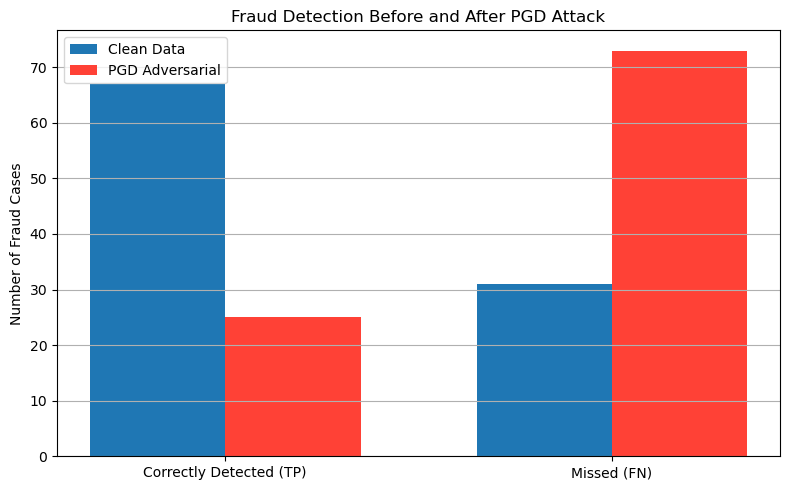

In [84]:
plot_fraud_detection_counts(model, test_loader, adv_loader)